# Options data cleaning — SPX

This notebook applies the same cleaning pipeline used in `data_cleaning.ipynb` (AAPL) to the SPX options dataset, following the methodology discussed for the thesis (see `data_quality_check.ipynb` for the preceding diagnostic pass, which only inspects the data without modifying it).

**Sections:**
1. Setup and imports
2. Load raw data
3. Basic type fixes (dates, strike price scale)
4. Restrict to call options
5. Bid/ask validity checks
6. Liquidity filter (volume and open interest)
7. Remove useless features
8. Merge stock price (S)
9. Moneyness (S/K)
10. Target variable
11. Merge historical volatility (60-day window)
12. Merge risk-free rate (90-day tenor)
13. Dividend yield (q)

## SPX options cleaning

### 1. Setup and imports

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# Confirm working directory so relative paths resolve correctly
# (this notebook is expected to sit at the project root, same folder as data_quality_check.ipynb)
print("Current working directory:", Path.cwd())

RAW_DATA_DIR = Path("data/raw")
SPX_OPTIONS_PATH = RAW_DATA_DIR / "SPX_options_prices.csv"

print("Looking for SPX options file at:", SPX_OPTIONS_PATH.resolve())
print("File exists:", SPX_OPTIONS_PATH.exists())

Current working directory: c:\Users\glmar\OneDrive\Bemacs Bocconi\TESI\Thesis\Priced-by-intelligence
Looking for SPX options file at: C:\Users\glmar\OneDrive\Bemacs Bocconi\TESI\Thesis\Priced-by-intelligence\data\raw\SPX_options_prices.csv
File exists: True


### 2. Load raw data

In [4]:
spx_raw = pd.read_csv(SPX_OPTIONS_PATH)

print("Shape:", spx_raw.shape)
spx_raw.head()

Shape: (24470893, 15)


,secid,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,optionid,cfadj,ss_flag,index_flag,issuer,exercise_style
0,108105,2020-08-31,2020-09-18,C,100000,3402.5,3408.2,0,611,133485146,1,0,1,CBOE S&P 500 INDEX,E
1,108105,2020-08-31,2020-09-18,C,1000000,2503.2,2508.0,0,37663,130915017,1,0,1,CBOE S&P 500 INDEX,E
2,108105,2020-08-31,2020-09-18,C,1100000,2403.4,2407.9,0,96,130915018,1,0,1,CBOE S&P 500 INDEX,E
3,108105,2020-08-31,2020-09-18,C,1200000,2303.5,2307.9,0,19,129372797,1,0,1,CBOE S&P 500 INDEX,E
4,108105,2020-08-31,2020-09-18,C,1225000,2278.8,2283.1,0,0,133142190,1,0,1,CBOE S&P 500 INDEX,E


In [5]:
spx_raw.dtypes

secid               int64
date                  str
exdate                str
cp_flag               str
strike_price        int64
best_bid          float64
best_offer        float64
volume              int64
open_interest       int64
optionid            int64
cfadj               int64
ss_flag             int64
index_flag          int64
issuer                str
exercise_style        str
dtype: object

### 3. Basic type fixes

Convert `date` and `exdate` to proper datetime objects, and rescale `strike_price` (OptionMetrics stores it multiplied by 1000).

In [6]:
# Work on a copy so the raw dataframe stays untouched for reference
spx = spx_raw.copy()

spx["date"] = pd.to_datetime(spx["date"])
spx["exdate"] = pd.to_datetime(spx["exdate"])

print(spx[["date", "exdate"]].dtypes)
print("Trading date range:", spx["date"].min(), "to", spx["date"].max())
print("Expiration date range:", spx["exdate"].min(), "to", spx["exdate"].max())

date      datetime64[us]
exdate    datetime64[us]
dtype: object
Trading date range: 2020-08-31 00:00:00 to 2025-08-29 00:00:00
Expiration date range: 2020-08-31 00:00:00 to 2026-07-17 00:00:00


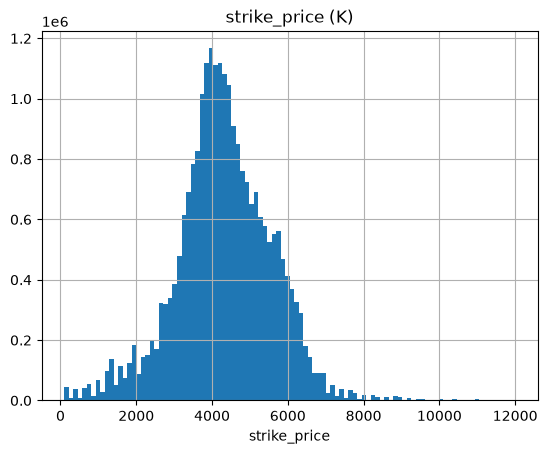

count    2.447089e+07
mean     4.321595e+03
std      1.264021e+03
min      1.000000e+02
25%      3.600000e+03
50%      4.275000e+03
75%      5.125000e+03
max      1.200000e+04
Name: strike_price, dtype: float64


In [7]:
# OptionMetrics stores strike_price multiplied by 1000
spx["strike_price"] = spx["strike_price"] / 1000

spx["strike_price"].hist(bins=100)
plt.title("strike_price (K)")
plt.xlabel("strike_price")
plt.show()

print(spx["strike_price"].describe())

### 4. Restrict to call options

Following Hutchinson, Lo and Poggio (1994), this analysis is restricted to call options at this stage. Put options are excluded from the dataset rather than reconciled against calls via put-call parity. This keeps option type unambiguous for both the Black-Scholes benchmark and the machine learning models without requiring `cp_flag` as an additional model feature.

In [8]:
# Restrict the dataset to call options only
n_before = len(spx)
spx = spx[spx["cp_flag"] == "C"].copy()
n_after = len(spx)

print(f"Rows before: {n_before}")
print(f"Rows after restricting to calls: {n_after}")
print(f"Rows removed: {n_before - n_after}")

Rows before: 24470893
Rows after restricting to calls: 12235448
Rows removed: 12235445


### 5. Bid/ask validity checks

This section addresses two distinct issues in `best_bid` and `best_offer`: (i) crossed markets, where `best_bid > best_offer`, which cannot represent a genuine tradable quote and are removed unconditionally; (ii) non-positive bids, which are not technically invalid but indicate illiquid, unreliable quotes. 

In [9]:
# Remove crossed markets: best_bid must not exceed best_offer
n_before = len(spx)
spx = spx[spx["best_bid"] <= spx["best_offer"]].copy()
n_after = len(spx)

print(f"Rows before: {n_before}")
print(f"Rows after removing crossed markets (best_bid > best_offer): {n_after}")
print(f"Rows removed: {n_before - n_after}")

Rows before: 12235448
Rows after removing crossed markets (best_bid > best_offer): 12235424
Rows removed: 24


In [10]:
# Remove rows with non-positive best_bid (zero or negative quotes are not valid tradable prices)
n_before = len(spx)
spx = spx[spx["best_bid"] > 0].copy()
n_after = len(spx)

print(f"Rows before: {n_before}")
print(f"Rows after removing non-positive best_bid: {n_after}")
print(f"Rows removed: {n_before - n_after}")

Rows before: 12235424
Rows after removing non-positive best_bid: 11648170
Rows removed: 587254


### 6. Liquidity filter (volume and open interest)

This section examines `volume` and `open_interest` as liquidity indicators. Options with no trading activity and no open positions are unlikely to carry a reliable price signal. Rows are removed only where both `volume` and `open_interest` are zero on the same day, indicating no trading activity and no outstanding positions on that contract. Using `volume == 0` alone would be too aggressive, since many actively traded contracts simply see no trades on a given day without being illiquid. Similarly, using `open_interest == 0` alone would risk removing contracts with genuine same-day trading activity, since open interest is typically reported as of the prior day's close and can lag newly active positions.

In [11]:
n_before = len(spx)
spx = spx[~((spx["volume"] == 0) & (spx["open_interest"] == 0))].copy()
n_after = len(spx)

print(f"Rows before: {n_before}")
print(f"Rows after liquidity filter: {n_after}")
print(f"Rows removed: {n_before - n_after}")

Rows before: 11648170
Rows after liquidity filter: 7806532
Rows removed: 3841638


## SPX feature engineering

### 7. Remove useless features

In [12]:
columns_to_drop = ["ss_flag", "cfadj", "index_flag", "issuer", "exercise_style", "cp_flag"]
spx = spx.drop(columns=columns_to_drop)

print("Remaining columns:", list(spx.columns))

Remaining columns: ['secid', 'date', 'exdate', 'strike_price', 'best_bid', 'best_offer', 'volume', 'open_interest', 'optionid']


### 8. Merge stock price (S)

Following Hutchinson, Lo and Poggio (1994), moneyness is constructed as `S/K` rather than using the stock price and strike price as separate inputs. This reflects the degree-one homogeneity property of the option pricing function in `(S, K)`, under the assumption that the return distribution of the underlying is independent of the price level (Merton, 1990, Theorem 8.9). Constructing this feature requires the underlying stock price for each option observation, obtained by merging with `SPX_security_prices.csv` on `date`.

In [13]:
security_prices = pd.read_csv(RAW_DATA_DIR / "SPX_security_prices.csv")
security_prices["date"] = pd.to_datetime(security_prices["date"])

Stylized fact check: fat tails in the underlying's return distribution.

Supports the discussion of lognormality in Section 2.3.

In [14]:
returns = np.log(security_prices["close"] / security_prices["close"].shift(1)).dropna()

excess_kurtosis = stats.kurtosis(returns)          # 0 under normality

std = returns.std()
observed_4sigma = (returns.abs() > 4 * std).sum() # How many days experienced a movement greater than four standard deviations
expected_4sigma = len(returns) * 2 * (1 - stats.norm.cdf(4)) # how many such large movements should you expect if returns were truly normally distributed
# stats.norm.cdf(4) = P(Z < 4): probability under the normal that a value stays below 4 std devs (very close to 1).
# 1 - cdf(4) = P(Z > 4): probability of exceeding +4 std devs (tiny).
# * 2 accounts for both tails, since we took abs(returns) above.
# * len(returns) scales that per-day probability into an expected COUNT over the sample: how many such moves normality predicts we'd see.

print(f"Daily log returns: n = {len(returns)}")
print(f"Excess kurtosis: {excess_kurtosis:.2f}")
print(f"Moves beyond 4 standard deviations: observed = {observed_4sigma}, "
      f"expected under normality = {expected_4sigma:.2f}")

Daily log returns: n = 1255
Excess kurtosis: 5.79
Moves beyond 4 standard deviations: observed = 5, expected under normality = 0.08


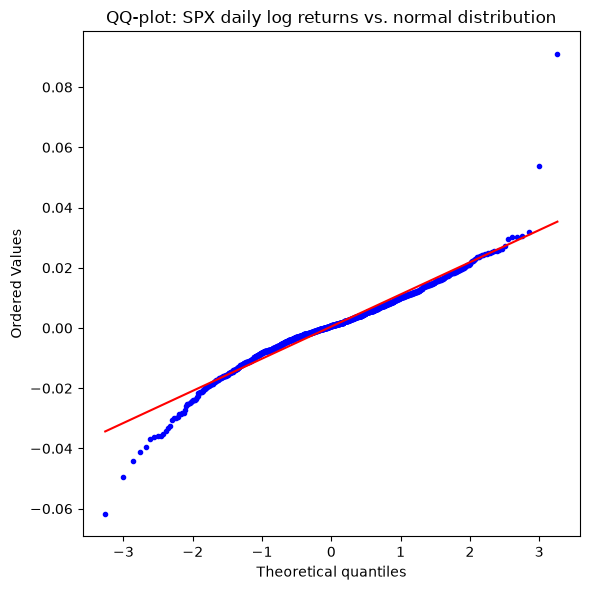

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(returns, dist="norm", plot=ax)
ax.set_title("QQ-plot: SPX daily log returns vs. normal distribution")
ax.get_lines()[0].set_markersize(3)
plt.tight_layout()
plt.savefig("qqplot_aapl_returns.pdf")
plt.show()

In [16]:
n_before = len(spx)
spx = spx.merge(security_prices[["date", "close"]], on="date", how="left")
n_after = len(spx)

print(f"Rows before merge: {n_before}")
print(f"Rows after merge: {n_after}")
print(f"Rows with missing underlying price after merge: {spx['close'].isna().sum()}")

Rows before merge: 7806532
Rows after merge: 7806532
Rows with missing underlying price after merge: 0


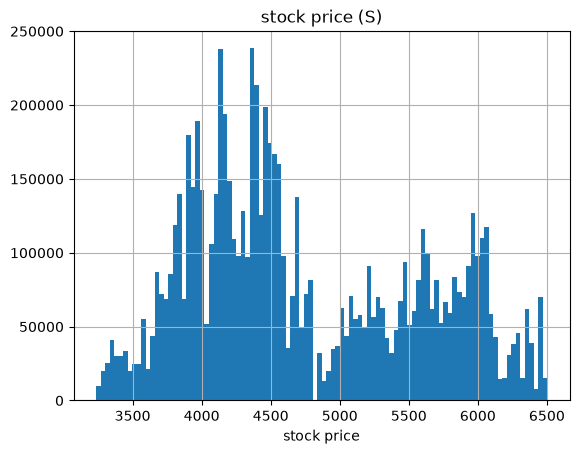

count    7.806532e+06
mean     4.747438e+03
std      8.207568e+02
min      3.236920e+03
25%      4.115680e+03
50%      4.505100e+03
75%      5.495520e+03
max      6.501860e+03
Name: close, dtype: float64


In [17]:
spx["close"].hist(bins=100)
plt.title("stock price (S)")
plt.xlabel("stock price")
plt.show()

print(spx["close"].describe())

### 9. Moneyness (S/K)

Moneyness is constructed as `S/K`, following Hutchinson, Lo and Poggio (1994), reflecting the degree-one homogeneity of the option pricing function in `(S, K)` under the assumption that the underlying's return distribution is independent of its price level (Merton, 1990, Theorem 8.9).

In [18]:
spx["moneyness (S/K)"] = spx["close"] / spx["strike_price"]

spx["moneyness (S/K)"].describe()

count    7.806532e+06
mean     1.182606e+00
std      1.396977e+00
min      4.218542e-01
25%      9.620537e-01
50%      1.016995e+00
75%      1.102806e+00
max      4.796560e+01
Name: moneyness (S/K), dtype: float64

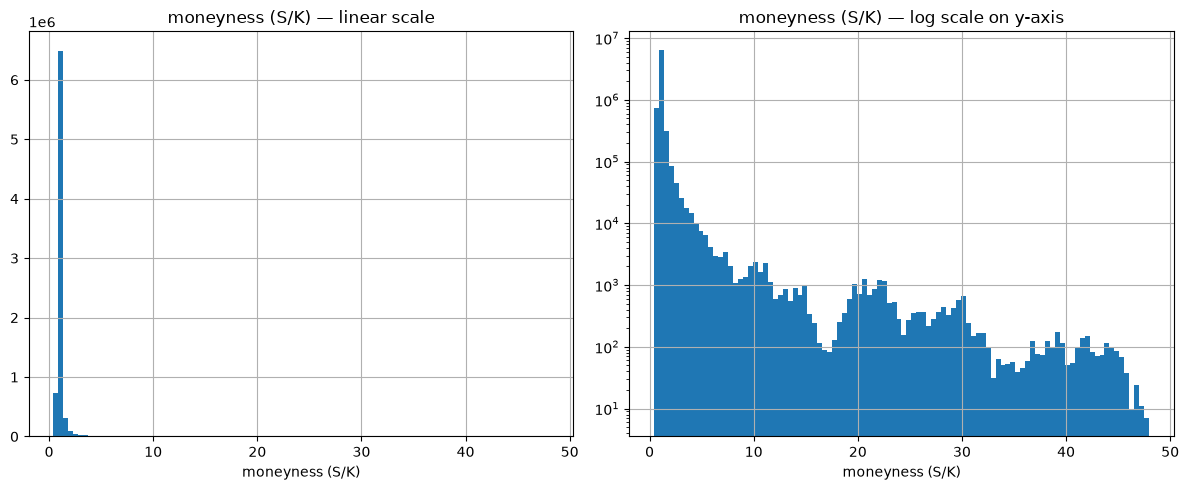

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

spx["moneyness (S/K)"].hist(bins=100, ax=axes[0])
axes[0].set_title("moneyness (S/K) — linear scale")
axes[0].set_xlabel("moneyness (S/K)")

spx["moneyness (S/K)"].hist(bins=100, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("moneyness (S/K) — log scale on y-axis")
axes[1].set_xlabel("moneyness (S/K)")

plt.tight_layout()
plt.show()

Investigate the gap in the distribution

### 10. Target variable 

The target variable is constructed as the option mid-price, `(best_bid + best_offer) / 2`, computed after the bid/ask validity checks in Section 5 to ensure both quotes are genuine.

In [20]:
spx["price"] = (spx["best_bid"] + spx["best_offer"]) / 2

spx["price"].describe()

count    7.806532e+06
mean     4.228941e+02
std      6.785425e+02
min      5.000000e-02
25%      3.205000e+01
50%      1.772500e+02
75%      5.043500e+02
max      6.301150e+03
Name: price, dtype: float64

In [21]:
spx.head()

,secid,date,exdate,strike_price,best_bid,best_offer,volume,open_interest,optionid,close,moneyness (S/K),price
0,108105,2020-08-31,2020-09-18,100.0,3402.5,3408.2,0,611,133485146,3500.31,35.003100,3405.35
1,108105,2020-08-31,2020-09-18,1000.0,2503.2,2508.0,0,37663,130915017,3500.31,3.500310,2505.60
2,108105,2020-08-31,2020-09-18,1100.0,2403.4,2407.9,0,96,130915018,3500.31,3.182100,2405.65
3,108105,2020-08-31,2020-09-18,1200.0,2303.5,2307.9,0,19,129372797,3500.31,2.916925,2305.70
4,108105,2020-08-31,2020-09-18,1250.0,2253.7,2258.0,0,20,129372798,3500.31,2.800248,2255.85


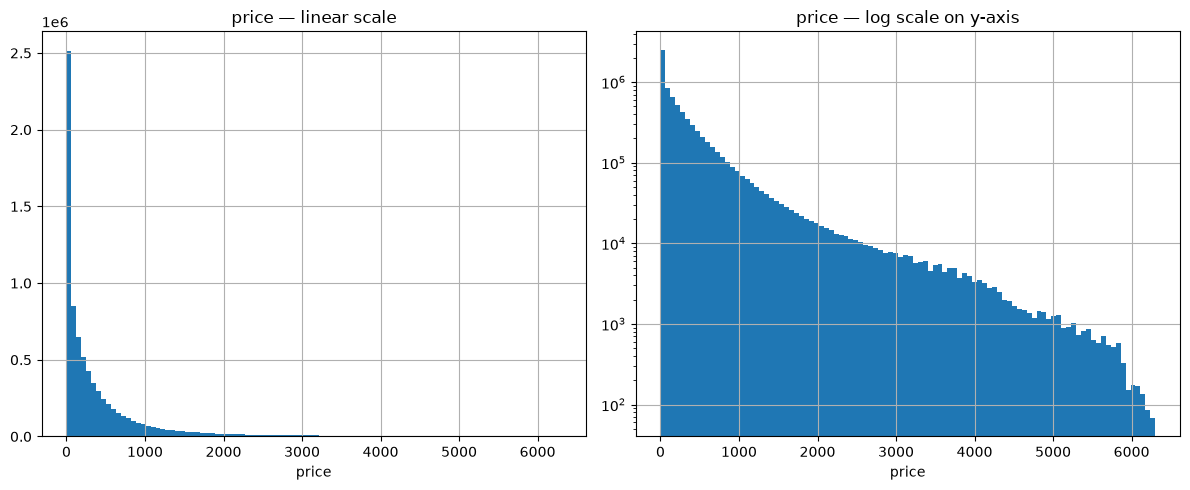

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

spx["price"].hist(bins=100, ax=axes[0])
axes[0].set_title("price — linear scale")
axes[0].set_xlabel("price")

spx["price"].hist(bins=100, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("price — log scale on y-axis")
axes[1].set_xlabel("price")

plt.tight_layout()
plt.show()

### 11. Merge historical volatility (60-day window)

Following Hutchinson, Lo and Poggio (1994), sigma is estimated as the realized volatility over a fixed 60-day trailing window, applied uniformly across all options regardless of their individual time to maturity. This choice may be revisited in favor of a per-option maturity-matched window later in the analysis.

In [23]:
historical_volatility = pd.read_csv(RAW_DATA_DIR / "SPX_historical_volatility.csv")
historical_volatility["date"] = pd.to_datetime(historical_volatility["date"])

hv_60 = historical_volatility[historical_volatility["days"] == 60]

In [24]:
n_before = len(spx)
spx = spx.merge(hv_60[["date", "volatility"]], on="date", how="left")
n_after = len(spx)

print(f"Rows before merge: {n_before}")
print(f"Rows after merge: {n_after}")
print(f"Rows with missing underlying price after merge: {spx['close'].isna().sum()}")
spx.head()

Rows before merge: 7806532
Rows after merge: 7806532
Rows with missing underlying price after merge: 0


,secid,date,exdate,strike_price,best_bid,best_offer,volume,open_interest,optionid,close,moneyness (S/K),price,volatility
0,108105,2020-08-31,2020-09-18,100.0,3402.5,3408.2,0,611,133485146,3500.31,35.003100,3405.35,0.111899
1,108105,2020-08-31,2020-09-18,1000.0,2503.2,2508.0,0,37663,130915017,3500.31,3.500310,2505.60,0.111899
2,108105,2020-08-31,2020-09-18,1100.0,2403.4,2407.9,0,96,130915018,3500.31,3.182100,2405.65,0.111899
3,108105,2020-08-31,2020-09-18,1200.0,2303.5,2307.9,0,19,129372797,3500.31,2.916925,2305.70,0.111899
4,108105,2020-08-31,2020-09-18,1250.0,2253.7,2258.0,0,20,129372798,3500.31,2.800248,2255.85,0.111899


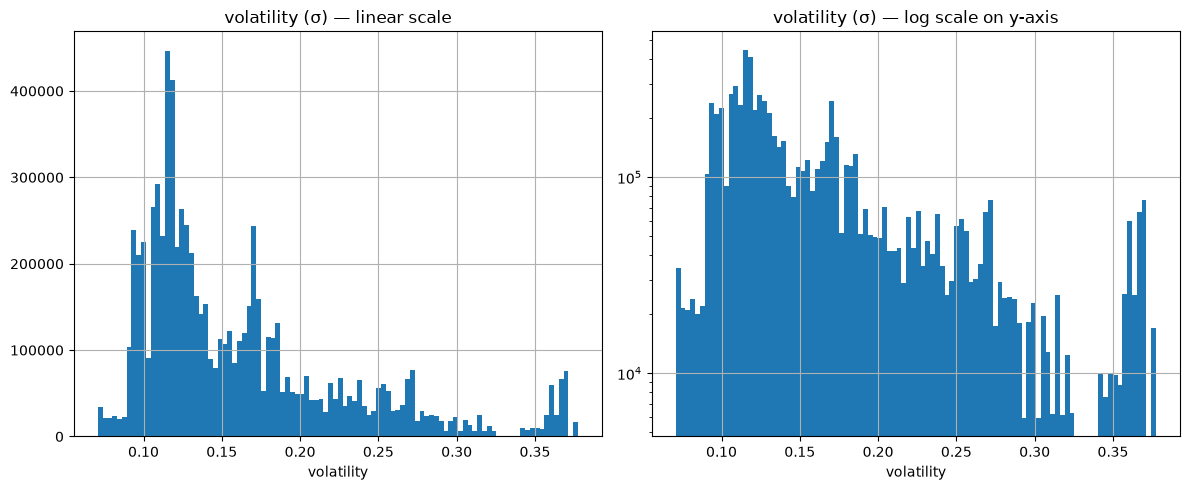

count    7.806532e+06
mean     1.625416e-01
std      6.733609e-02
min      7.077300e-02
25%      1.149060e-01
50%      1.381890e-01
75%      1.874180e-01
max      3.774580e-01
Name: volatility, dtype: float64


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

spx["volatility"].hist(bins=100, ax=axes[0])
axes[0].set_title("volatility (σ) — linear scale")
axes[0].set_xlabel("volatility")

spx["volatility"].hist(bins=100, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("volatility (σ) — log scale on y-axis")
axes[1].set_xlabel("volatility")

plt.tight_layout()
plt.show()

print(spx["volatility"].describe())

### 12. Merge risk-free rate (90-day tenor)

For each date, the zero-coupon rate closest to a 90-day maturity is selected from the Zero_Curve file, rather than requiring an exact match, since available tenors vary slightly around 90 days (89, 90, 91, ...) rather than following fixed standardized bins.

In [26]:
riskfree = pd.read_csv(RAW_DATA_DIR / "riskfree_rate.csv")
riskfree["date"] = pd.to_datetime(riskfree["date"])

In [27]:
riskfree["days_diff"] = (riskfree["days"] - 90).abs()
riskfree_90 = riskfree.loc[riskfree.groupby("date")["days_diff"].idxmin()][["date", "rate"]]

n_before = len(spx)
spx = spx.merge(riskfree_90, on="date", how="left")
n_after = len(spx)

print(f"Rows before merge: {n_before}")
print(f"Rows after merge: {n_after}")
print(f"Rows with missing rate after merge: {spx['rate'].isna().sum()}")

Rows before merge: 7806532
Rows after merge: 7806532
Rows with missing rate after merge: 0


In [28]:
spx["rate"] = spx["rate"] / 100
print(spx["rate"].describe())

count    7.806532e+06
mean     3.339521e-02
std      2.107331e-02
min      1.025680e-03
25%      5.985910e-03
50%      4.428789e-02
75%      5.136799e-02
max      5.537731e-02
Name: rate, dtype: float64


In [29]:
spx.head()

,secid,date,exdate,strike_price,best_bid,best_offer,volume,open_interest,optionid,close,moneyness (S/K),price,volatility,rate
0,108105,2020-08-31,2020-09-18,100.0,3402.5,3408.2,0,611,133485146,3500.31,35.003100,3405.35,0.111899,0.002148
1,108105,2020-08-31,2020-09-18,1000.0,2503.2,2508.0,0,37663,130915017,3500.31,3.500310,2505.60,0.111899,0.002148
2,108105,2020-08-31,2020-09-18,1100.0,2403.4,2407.9,0,96,130915018,3500.31,3.182100,2405.65,0.111899,0.002148
3,108105,2020-08-31,2020-09-18,1200.0,2303.5,2307.9,0,19,129372797,3500.31,2.916925,2305.70,0.111899,0.002148
4,108105,2020-08-31,2020-09-18,1250.0,2253.7,2258.0,0,20,129372798,3500.31,2.800248,2255.85,0.111899,0.002148


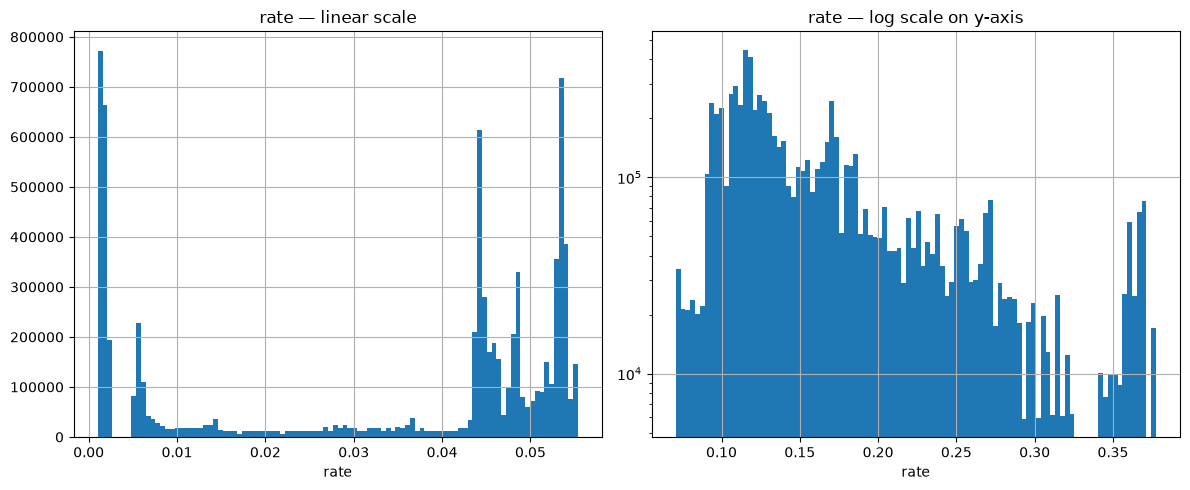

count    7.806532e+06
mean     3.339521e-02
std      2.107331e-02
min      1.025680e-03
25%      5.985910e-03
50%      4.428789e-02
75%      5.136799e-02
max      5.537731e-02
Name: rate, dtype: float64


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

spx["rate"].hist(bins=100, ax=axes[0])
axes[0].set_title("rate — linear scale")
axes[0].set_xlabel("rate")

spx["volatility"].hist(bins=100, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("rate — log scale on y-axis")
axes[1].set_xlabel("rate")

plt.tight_layout()
plt.show()

print(spx["rate"].describe())

### 13. Dividend yield (q)

#### Exclude same-day expirations (T = 0)

Options with zero days to expiration are excluded, since T = 0 causes a division by zero in the Black-Scholes d1/d2 terms. This exclusion is applied regardless of the broader minimum-maturity threshold decision (deferred to post-training analysis, following Hutchinson, Lo and Poggio, 1994), since it addresses a mathematical requirement of the pricing formula itself rather than a data-quality judgment.

In [31]:
spx["days_to_maturity"] = (spx["exdate"] - spx["date"]).dt.days
spx["T"] = spx["days_to_maturity"] / 365

spx["T"].describe()

count    7.806532e+06
mean     2.123470e-01
std      2.254422e-01
min      0.000000e+00
25%      4.657534e-02
50%      1.232877e-01
75%      3.068493e-01
max      9.753425e-01
Name: T, dtype: float64

In [32]:
n_before = len(spx)
spx = spx[spx["T"] > 0].copy()
n_after = len(spx)

print(f"Rows before: {n_before}")
print(f"Rows after excluding T = 0: {n_after}")
print(f"Rows removed: {n_before - n_after}")

Rows before: 7806532
Rows after excluding T = 0: 7688150
Rows removed: 118382


Compute the median.

In [33]:
print(f"SPX — median T: {spx['T'].median()*365:.0f} days, "
      f"range: {spx['T'].min()*365:.0f} - {spx['T'].max()*365:.0f} days")

SPX — median T: 46 days, range: 1 - 356 days


Unlike the AAPL dividend file (discrete declared dividend events requiring an as-of merge and annualization by payment frequency), `SPX_dividend_yield.csv` already provides a daily, continuously-compounded index dividend yield (`rate`) for each trading date. `q` is therefore obtained with a direct merge on `date`, with no as-of logic, frequency annualization, or stock-split correction required (SPX, as an index, is not subject to stock splits).

In [34]:
spx_div = pd.read_csv(RAW_DATA_DIR / "SPX_dividend_yield.csv")
spx_div["date"] = pd.to_datetime(spx_div["date"])

print(f"Rows: {len(spx_div):,}")
print(f"Columns: {list(spx_div.columns)}")

print(spx_div.sort_values("date").head(5))

Rows: 1,256
Columns: ['secid', 'date', 'rate']
    secid       date      rate
0  108105 2020-08-31  1.588993
1  108105 2020-09-01  1.590263
2  108105 2020-09-02  1.572741
3  108105 2020-09-03  1.577477
4  108105 2020-09-04  1.582210


In [35]:
spx_div = spx_div.rename(columns={"rate": "q"})
spx_div["q"] = spx_div["q"] / 100

n_before = len(spx)
spx = spx.merge(spx_div[["date", "q"]], on="date", how="left")
n_after = len(spx)

print(f"Rows before merge: {n_before}")
print(f"Rows after merge: {n_after}")
print(f"Rows with missing q after merge: {spx['q'].isna().sum()}")
spx["q"].describe()

Rows before merge: 7688150
Rows after merge: 7688150
Rows with missing q after merge: 0


count    7.688150e+06
mean     1.192291e-02
std      2.489153e-03
min      6.496350e-03
25%      9.656680e-03
50%      1.216691e-02
75%      1.384684e-02
max      1.680734e-02
Name: q, dtype: float64

In [36]:
spx.head()

,secid,date,exdate,strike_price,best_bid,best_offer,volume,open_interest,optionid,close,moneyness (S/K),price,volatility,rate,days_to_maturity,T,q
0,108105,2020-08-31,2020-09-18,100.0,3402.5,3408.2,0,611,133485146,3500.31,35.003100,3405.35,0.111899,0.002148,18,0.049315,0.01589
1,108105,2020-08-31,2020-09-18,1000.0,2503.2,2508.0,0,37663,130915017,3500.31,3.500310,2505.60,0.111899,0.002148,18,0.049315,0.01589
2,108105,2020-08-31,2020-09-18,1100.0,2403.4,2407.9,0,96,130915018,3500.31,3.182100,2405.65,0.111899,0.002148,18,0.049315,0.01589
3,108105,2020-08-31,2020-09-18,1200.0,2303.5,2307.9,0,19,129372797,3500.31,2.916925,2305.70,0.111899,0.002148,18,0.049315,0.01589
4,108105,2020-08-31,2020-09-18,1250.0,2253.7,2258.0,0,20,129372798,3500.31,2.800248,2255.85,0.111899,0.002148,18,0.049315,0.01589


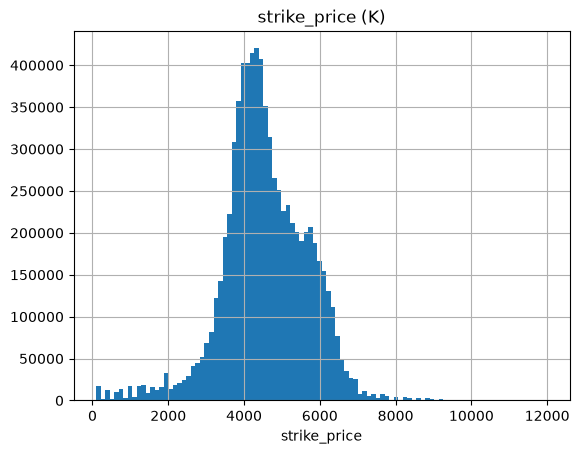

count    7.688150e+06
mean     1.192291e-02
std      2.489153e-03
min      6.496350e-03
25%      9.656680e-03
50%      1.216691e-02
75%      1.384684e-02
max      1.680734e-02
Name: q, dtype: float64


In [37]:
spx["strike_price"].hist(bins=100)
plt.title("strike_price (K)")
plt.xlabel("strike_price")
plt.show()


print(spx["q"].describe())

In [38]:
spx.to_csv(RAW_DATA_DIR.parent / "processed" / "SPX_cleaned.csv", index=False)
print(f"Saved {len(spx)} rows to SPX_cleaned.csv")

OSError: [Errno 22] Invalid argument: 'data\\processed\\SPX_cleaned.csv'

## Summary

In [ ]:
# Sample descriptives for the methodology chapter
security_prices = pd.read_csv("data/raw/SPX_security_prices.csv", parse_dates=["date"])
security_prices = security_prices.sort_values("date")

first_close = security_prices["close"].iloc[0]
last_close = security_prices["close"].iloc[-1]

print(f"Sample period: {security_prices['date'].min().date()} to {security_prices['date'].max().date()}")
print(f"Trading days: {security_prices['date'].nunique()}")
print(f"Underlying: {first_close:.2f} -> {last_close:.2f} "
      f"({(last_close / first_close - 1) * 100:.1f}%)")
print(f"Underlying range: {security_prices['close'].min():.2f} - {security_prices['close'].max():.2f}")
print()
print(f"Observations after cleaning: {len(spx):,}")
print(f"Distinct contracts: {spx['optionid'].nunique():,}")
print(f"Trading days retained: {spx['date'].nunique()}")
print(f"Option price range: {spx['price'].min():.2f} - {spx['price'].max():.2f}")
print(f"Moneyness range: {spx['moneyness (S/K)'].min():.3f} - {spx['moneyness (S/K)'].max():.3f}")
print(f"Maturity range (years): {spx['T'].min():.4f} - {spx['T'].max():.4f}")

Sample period: 2020-08-31 to 2025-08-29
Trading days: 1256
Underlying: 3500.31 -> 6460.26 (84.6%)
Underlying range: 3236.92 - 6501.86

Observations after cleaning: 7,688,150
Distinct contracts: 211,827
Trading days retained: 1256
Option price range: 0.05 - 6301.15
Moneyness range: 0.422 - 47.966
Maturity range (years): 0.0027 - 0.9753
